In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


In [3]:
df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


# Inspection of Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


Conclusion : Need of Encoding 

In [5]:
df.shape

(2000, 8)

In [6]:
df.isna().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
(df['answer'].value_counts()/df.shape[0])*100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: count, dtype: float64

<Axes: xlabel='answer', ylabel='count'>

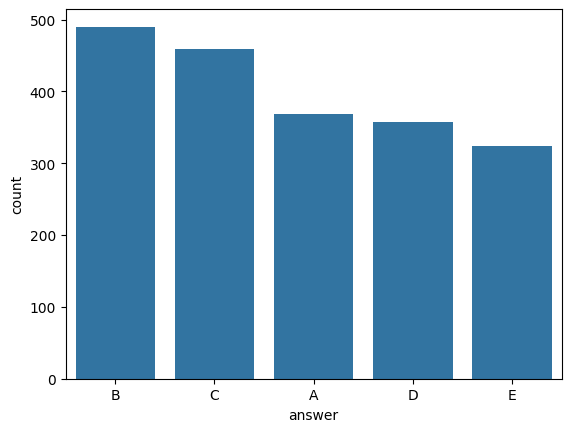

In [9]:
import seaborn as sns

sns.countplot(x=df['answer'], data=df, order=df['answer'].value_counts().index)

In [10]:
x=df['answer'].value_counts().max() +  df['answer'].value_counts().min()

print("Sum of Most frequent and least frequent options in answer column =",x)

Sum of Most frequent and least frequent options in answer column = 814


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="answer")
y = df['answer']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Creating Vocab 
* removing punctuation
* split by space 

In [12]:
import string
has_punctuation = X_train["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[ True]


In [13]:
import string
def clean_text(text):
    text=text.lower()
    translator=str.maketrans('','',string.punctuation) #nothing,nothing,delete punctuation 
    text=text.translate(translator)
    return text
    

In [14]:
for col in ["prompt", "A", "B", "C", "D", "E"]:
    X_train[col] = X_train[col].apply(clean_text)
    X_val[col] = X_val[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)

In [15]:
#verifying 
has_punctuation = X_train["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[False]


In [16]:
vocab=set()
for text in X_train["prompt"]:
    vocab.update(text.split())
print(len(vocab))

859


In [17]:
def map3(y_true, top3_preds):
    score = 0

    for actual, pred in zip(y_true, top3_preds):
        if actual == pred[0]:
            score += 1.0

        elif actual == pred[1]:
            score += 0.5

        elif actual == pred[2]:
            score += 1/3

    return score / len(y_true)

In [18]:
counts = df['answer'].value_counts()

top3 = counts.index[:3].tolist()

print(top3)

['B', 'C', 'A']


In [19]:
y_pred = [top3] * len(X_train)

In [20]:
print("Majority class baseline : ",round(map3(y_train,y_pred),3)) #train dataset and its a dummy classifier

Majority class baseline :  0.421


In [21]:
train_text=pd.concat([
    X_train["prompt"],
    X_train["A"],
    X_train["B"],
    X_train["C"],
    X_train["D"],
    X_train["E"]
])

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer= TfidfVectorizer( ngram_range=(1,3), lowercase=True,
    max_features=80000,
    min_df=2)
vectorizer.fit(train_text)


TfidfVectorizer(max_features=80000, min_df=2, ngram_range=(1, 3))

In [23]:
print(len(vectorizer.vocabulary_))

25264


In [24]:
def transform_columns(df,vectorizer):
    return (
        vectorizer.transform(df["prompt"]),
        vectorizer.transform(df["A"]),
        vectorizer.transform(df["B"]),
        vectorizer.transform(df["C"]),
        vectorizer.transform(df["D"]),
        vectorizer.transform(df["E"])
    )

In [25]:
prompt_vec, A_vec, B_vec, C_vec, D_vec, E_vec = transform_columns(X_train, vectorizer)

prompt_val, A_val, B_val, C_val, D_val, E_val = transform_columns(X_val, vectorizer)


In [26]:
from sklearn.metrics.pairwise import cosine_similarity
print("shape of comparing prompt with A_vector",cosine_similarity(prompt_vec, A_vec).diagonal().shape)
scores = {
    'A': cosine_similarity(prompt_vec, A_vec).diagonal(),
    'B': cosine_similarity(prompt_vec, B_vec).diagonal(),
    'C': cosine_similarity(prompt_vec, C_vec).diagonal(),
    'D': cosine_similarity(prompt_vec, D_vec).diagonal(),
    'E': cosine_similarity(prompt_vec, E_vec).diagonal()
}
scores_val = {
    'A': cosine_similarity(prompt_val, A_val).diagonal(),
    'B': cosine_similarity(prompt_val, B_val).diagonal(),
    'C': cosine_similarity(prompt_val, C_val).diagonal(),
    'D': cosine_similarity(prompt_val, D_val).diagonal(),
    'E': cosine_similarity(prompt_val, E_val).diagonal()
}



shape of comparing prompt with A_vector (1600,)


In [27]:
def top3preds(scores_dict):
    preds = []

    for i in range(len(scores_dict["A"])):

        row_scores = {
            "A": scores_dict["A"][i],
            "B": scores_dict["B"][i],
            "C": scores_dict["C"][i],
            "D": scores_dict["D"][i],
            "E": scores_dict["E"][i]
        }

        top3 = []

        for k in range(3):

            best_opt = None
            best_score = -1

            for option, score in row_scores.items():

                if score > best_score:
                    best_score = score
                    best_opt = option

            top3.append(best_opt)
            row_scores.pop(best_opt)

        preds.append(top3)

    return preds

top3_list_val=top3preds(scores_val)
top3_list_train=top3preds(scores)

In [28]:
map3(y_train,top3_list_train)

0.3162499999999987

In [29]:
map3(y_val,top3_list_val)

0.2849999999999997

### LR model


In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
def expand_to_binary(X, y):
    rows = []
    for (_, row), label in zip(X.iterrows(), y):
        for opt in ['A', 'B', 'C', 'D', 'E']:
            rows.append({
                'text': row['prompt'] + ' ' + row[opt],
                'label': 1 if label == opt else 0
            })
    return pd.DataFrame(rows)

train_binary = expand_to_binary(X_train, y_train)

In [32]:
train_binary.shape

(8000, 2)

In [33]:
lr_vec = TfidfVectorizer(ngram_range=(1,3), max_features=80000, min_df=2)
X_train = lr_vec.fit_transform(train_binary['text'])

lr=LogisticRegression(max_iter=1000)
lr.fit(X_train, train_binary['label'])


LogisticRegression(max_iter=1000)

In [34]:
def predict_top3(row):

    # Step 1: Create five complete sentences by combining
    # the question (prompt) with each answer option (A-E)
    texts = [
        row['prompt'] + " " + row['A'],
        row['prompt'] + " " + row['B'],
        row['prompt'] + " " + row['C'],
        row['prompt'] + " " + row['D'],
        row['prompt'] + " " + row['E']
    ]

    # Step 2: Convert these sentences into TF-IDF vectors
    text_vectors = lr_vec.transform(texts)

    # Step 3: Logistic Regression predicts the probability
    # that each option is the correct answer (class = 1)
    probabilities = lr.predict_proba(text_vectors)[:, 1]

    # Step 4: Pair each option with its probability
    option_scores = list(zip(['A', 'B', 'C', 'D', 'E'], probabilities))

    # Example:
    # [('A', 0.15), ('B', 0.82), ('C', 0.40), ('D', 0.05), ('E', 0.70)]

    # Step 5: Sort options from highest probability to lowest
    option_scores.sort(key=lambda x: x[1], reverse=True)

    # Step 6: Return only the top 3 option names
    return [option for option, score in option_scores[:3]]

# Predict the top 3 answers for every question

top3_val = []
for _, row in X_val.iterrows():   # ← X_val has prompt, A, B, C, D, E columns
    top3_val.append(predict_top3(row))

score = map3(y_val, top3_val)
print("Validation MAP@3:", score)

Validation MAP@3: 0.995


In [35]:
top3_test = []
for _, row in test_df.iterrows():
    top3_test.append(predict_top3(row))

In [36]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'answer': [' '.join(preds) for preds in top3_test]  # format: "A B C"
})

submission.to_csv('submission.csv', index=False)